# Ejercicio PCA (Principal Component Analysis)
En este ejercicio vas a trabajar con un dataset de información de ciudadanos como el estado civil, número de hijos, qué gastos e ingresos tiene, etc...

Se cuenta con un target, que es si el ciudadano va a alquilar o a comprar una vivienda. Para ello,  con PCA

### Importamos librerias
Principales librerías que usarás durante el notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

### Cargamos datos de entrada
1. Carga el csv *comprar_alquilar.csv*
2. Obtén la información básica: columnas, dimensiones, descripción de las variables, missings...

In [2]:
df = pd.read_csv('data/comprar_alquilar.csv')

print(df.info())
print(df.describe())
print(f"\nMissings:\n{df.isnull().sum()}")

<class 'pandas.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ingresos        202 non-null    int64
 1   gastos_comunes  202 non-null    int64
 2   pago_coche      202 non-null    int64
 3   gastos_otros    202 non-null    int64
 4   ahorros         202 non-null    int64
 5   vivienda        202 non-null    int64
 6   estado_civil    202 non-null    int64
 7   hijos           202 non-null    int64
 8   trabajo         202 non-null    int64
 9   comprar         202 non-null    int64
dtypes: int64(10)
memory usage: 15.9 KB
None
          ingresos  gastos_comunes  pago_coche  gastos_otros       ahorros  \
count   202.000000      202.000000  202.000000    202.000000    202.000000   
mean   4958.995050      971.584158  211.742574    515.425743  38749.668317   
std    1682.862556      272.106351  124.940754    168.103075  17365.231870   
min    2008.000000      384.00000

### Visualicemos las dimensiones
Realiza un análisis univariante. Realiza la gráfica que consideres para cada variable, diferenciando por colores el target (*comprar*).

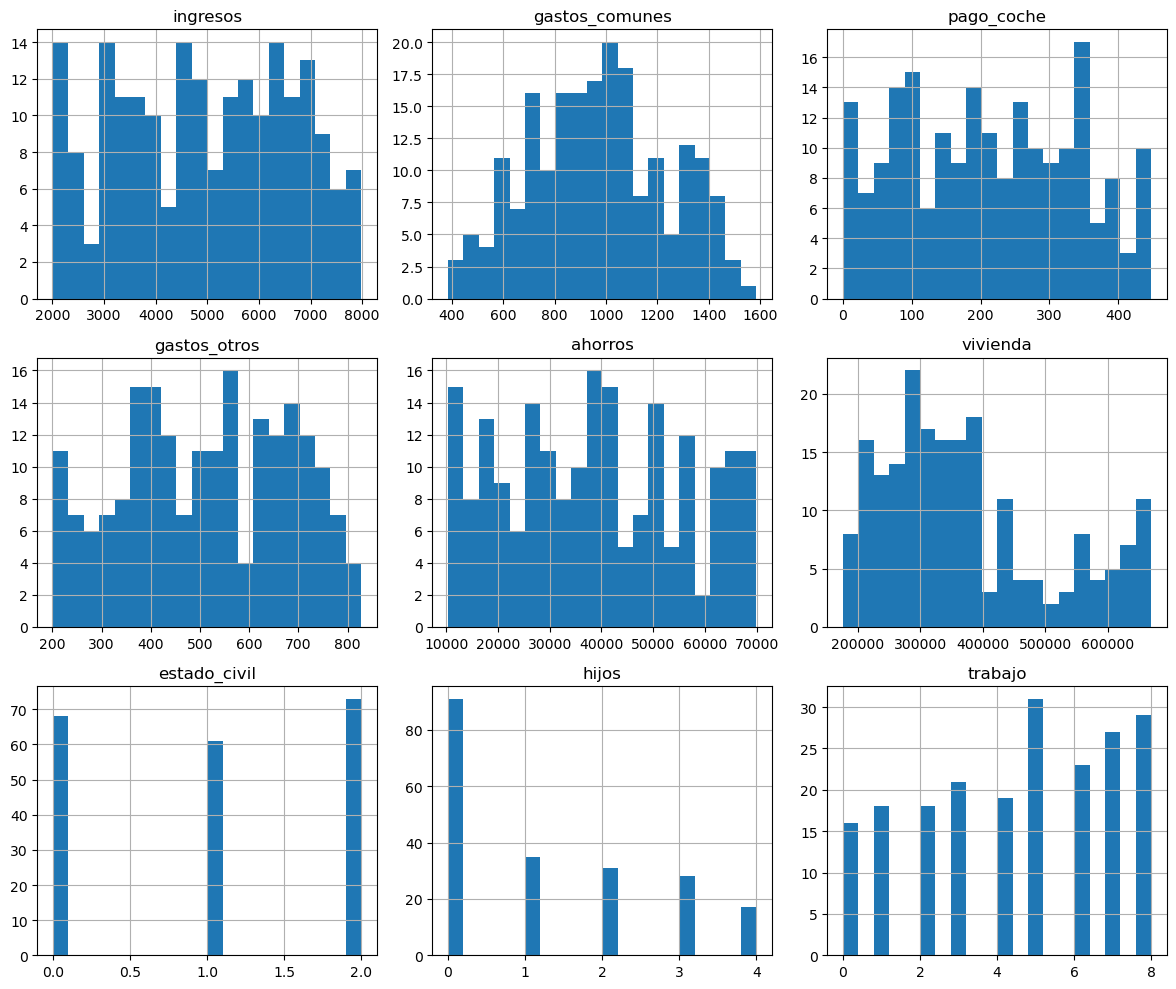

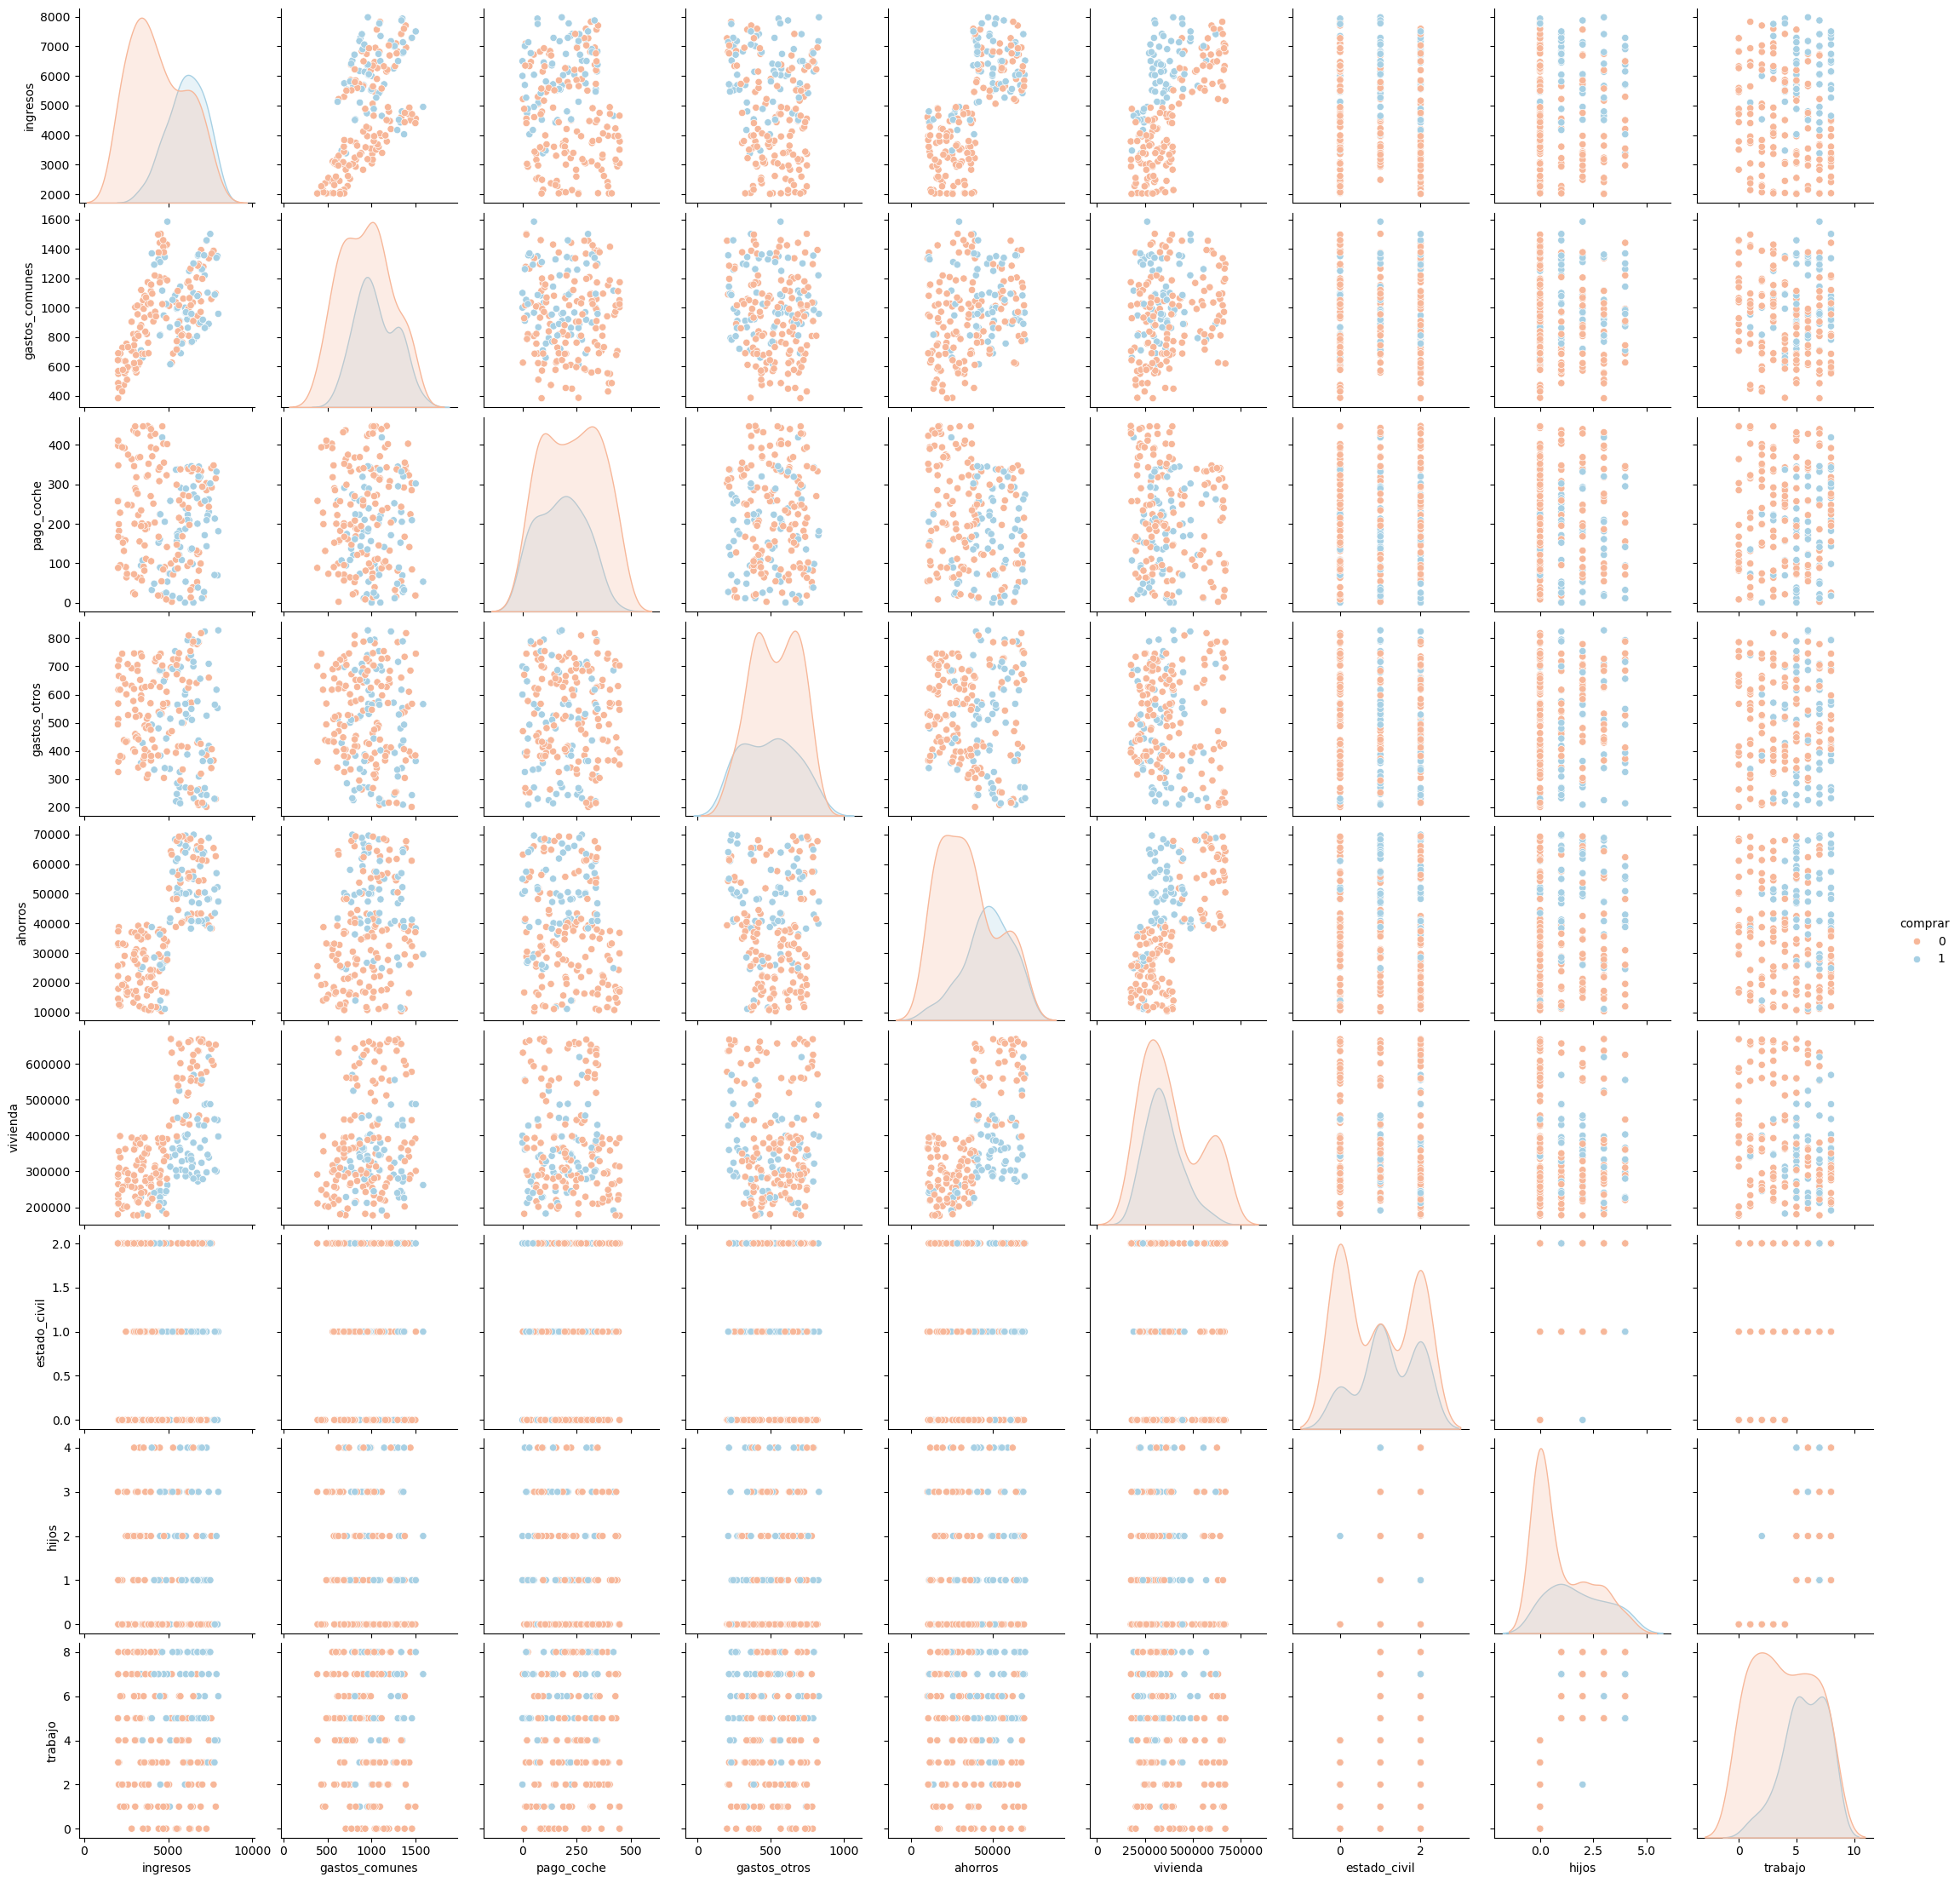

In [3]:
# Histogramas para cada variable numérica
df.drop('comprar', axis=1).hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

# Ejemplo de análisis diferenciando por el target
sns.pairplot(df, hue='comprar', palette='RdBu')

## Estandariza los datos
Como el objetivo de estos primeros apartados no es encontrar el mejor modelo con el mejor accuracy, por sencillez, no es necesario dividir en train y test.

In [4]:
X = df.drop('comprar', axis=1)
y = df['comprar']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=9)
pca.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",9
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

## Aplicamos PCA
Aplica el algoritmo de PCA para 9 components, es decir, para todas las features

In [11]:
pca = PCA(n_components=9)

# Ajustamos y transformamos los datos ya escalados (X_scaled)
X_pca = pca.fit_transform(X_scaled)

# Creamos un DataFrame para visualizar los nuevos componentes
componentes_names = [f'PC{i+1}' for i in range(9)]
df_pca = pd.DataFrame(data=X_pca, columns=componentes_names)

# Mostramos los primeros registros de las nuevas dimensiones
print("Nuevas dimensiones (Componentes Principales):")
df_pca.head()

Nuevas dimensiones (Componentes Principales):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,1.321915,-0.222950,1.599863,-0.885014,0.646617,-0.700208,0.318031,-0.751809,0.269984
1,1.147878,1.716967,0.395722,-0.447960,-0.687805,-0.231969,1.542487,0.221799,0.438425
2,0.090369,1.836066,1.359382,0.337505,0.742387,0.593030,-1.540495,0.668120,0.153463
3,3.455898,-0.078279,-0.202382,-1.573584,-0.068551,-0.051945,0.909409,0.684486,-0.129045
4,0.916933,-1.184676,0.190036,0.117804,-0.147753,-0.619750,-0.450419,0.194341,0.687452


Varianza por PC: [0.29913557 0.23294923 0.11711241 0.10685622 0.09635279 0.05629866
 0.04145579 0.03017819 0.01966115]
Varianza acumulada: [0.29913557 0.5320848  0.64919721 0.75605343 0.85240621 0.90870487
 0.95016066 0.98033885 1.        ]
Varianza con 9 PCs: 1.0000


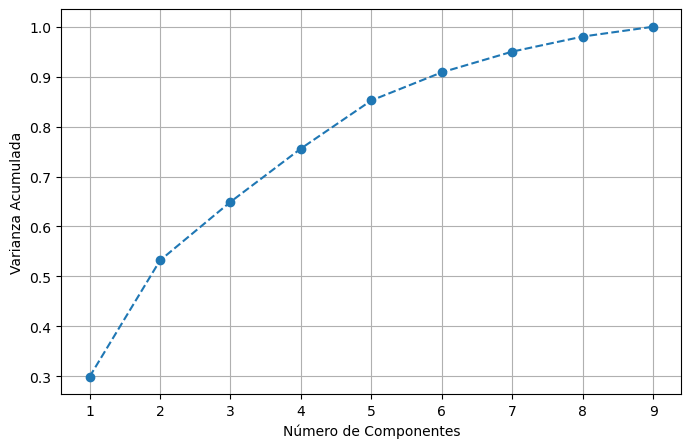

In [8]:
# 1. Varianza por componente
print("Varianza por PC:", pca.explained_variance_ratio_)

# 2. Varianza acumulada
cum_var = np.cumsum(pca.explained_variance_ratio_)
print("Varianza acumulada:", cum_var)

# 3. Varianza con 9 componentes
print(f"Varianza con 9 PCs: {cum_var[8]:.4f}")

# Gráfica de varianza acumulada
plt.figure(figsize=(8,5))
plt.plot(range(1, 10), cum_var, marker='o', linestyle='--')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada')
plt.grid(True)

### Veamos cómo de buenos predictores son las nuevas dimensiones
Responde a las siguientes preguntas:
1. ¿Cuánta varianza explica cada Principal Component?

Componente	Varianza Individual

PC1	29.74%

PC2	22.56%

PC3	11.83%

PC4	10.51%

PC5	10.36%

PC6	6.66%

PC7	4.27%

PC8	3.01%

PC9	1.06%

2. ¿Y de manera acumulada empezando por el PC1?

PC1: 29.74%

PC2: 52.30%

PC3: 64.13%

PC4: 74.64%

PC5: 85.00%

PC6: 91.66%

PC7: 95.93%

PC8: 98.94%

PC9: 100.00%

3. ¿Cuánta varianza explicarían sólo 5 componentes?

PC5: 85.00%

### Graficamos la variacion explicada acumulada
Representa en un diagrama de lineas la evolución de la varianza acumulada en función de los PC

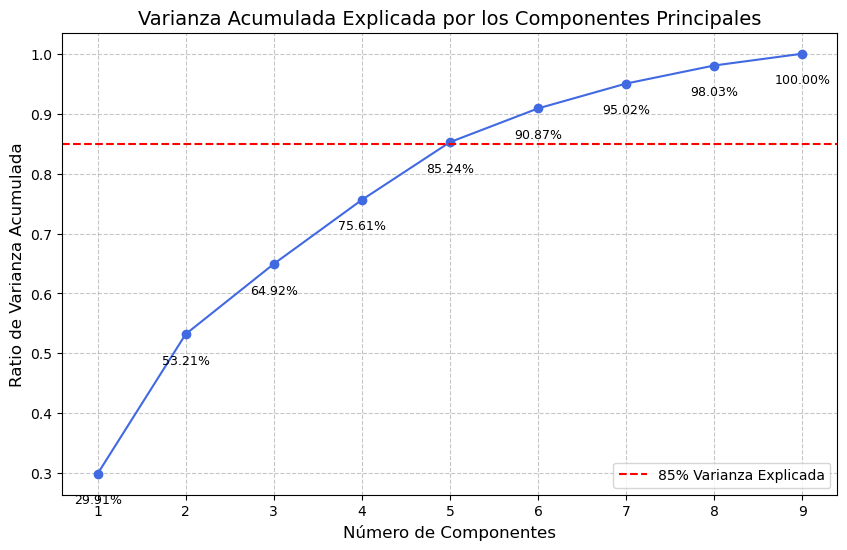

In [10]:
# Calculamos la varianza acumulada
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

# Creamos la gráfica
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='-', color='royalblue')

# Configuración de ejes y títulos
plt.title('Varianza Acumulada Explicada por los Componentes Principales', fontsize=14)
plt.xlabel('Número de Componentes', fontsize=12)
plt.ylabel('Ratio de Varianza Acumulada', fontsize=12)
plt.xticks(range(1, len(varianza_acumulada) + 1))
plt.grid(True, linestyle='--', alpha=0.7)

# Añadimos una línea de referencia en el 85% (punto de decisión común)
plt.axhline(y=0.85, color='r', linestyle='--', label='85% Varianza Explicada')

# Etiquetas de los valores en los puntos
for i, valor in enumerate(varianza_acumulada):
    plt.text(i + 1, valor - 0.05, f'{valor:.2%}', ha='center', fontsize=9)

plt.legend(loc='lower right')
plt.show()

### Veamos la correlación entre las nuevas componentes y las dimensiones originales
Representa en un mapa de calor los PCA vs las variables originales. Esta información la puedes obtener del atributo de PCA *components_*.

Text(0.5, 1.0, 'Correlación PCA vs Variables Originales')

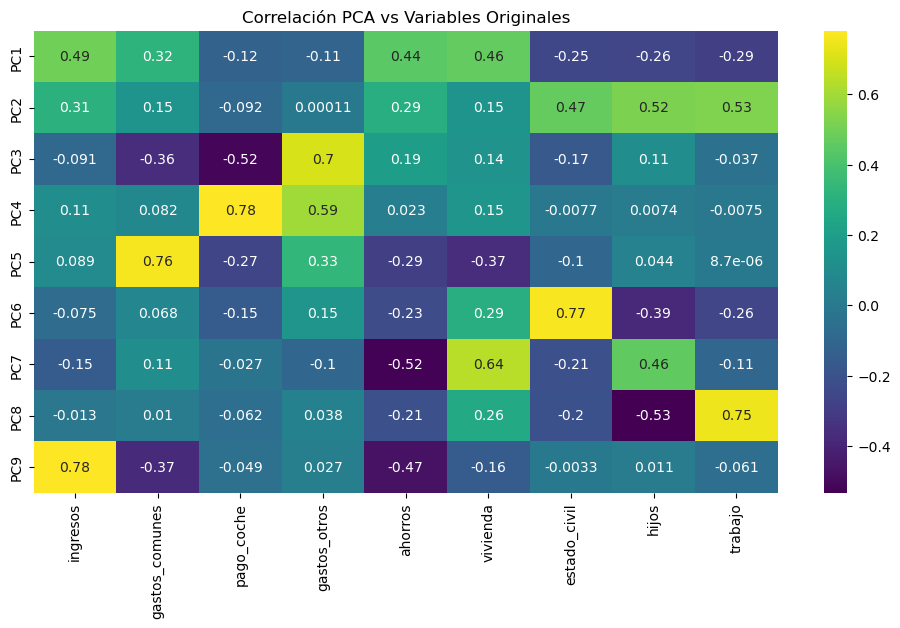

In [9]:
plt.figure(figsize=(12,6))
sns.heatmap(pca.components_, 
            cmap='viridis', 
            yticklabels=[f'PC{i+1}' for i in range(9)],
            xticklabels=X.columns,
            annot=True)
plt.title("Correlación PCA vs Variables Originales")

## Predicciones
1. Divide en train y test
2. Prepara un pipeline compuesto por:
    - StandardScaler,
    - PCA de 5 componentes
    - Un clasificador
3. Entrena
4. Predice con test
5. Calcula el accuracy score en train y test
6. Representa la matriz de confusión
7. ¿Qué combinación de parámetros y componentes mejoraría el accuracy en test?
8. Vuelve a iterar de nuevo con un gridsearch
9. Guarda tu mejor modelo

Accuracy Train: 0.8137
Accuracy Test: 0.7561


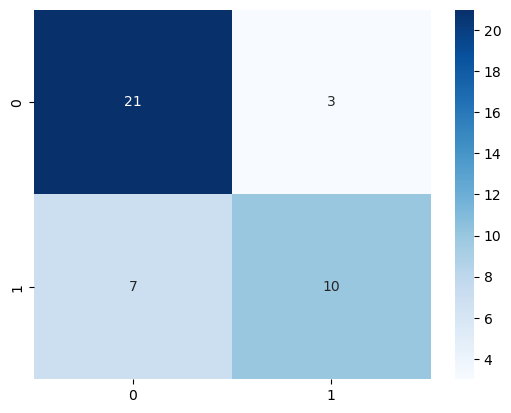

Mejores parámetros: {'classifier__C': 10, 'pca__n_components': 9}
Mejor Score: 0.943939393939394


['mejor_modelo_pca.pkl']

In [ ]:
# 1. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=5)),
    ('classifier', LogisticRegression())
])

# 3, 4 y 5. Entrenar y Evaluar
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print(f"Accuracy Train: {pipe.score(X_train, y_train):.4f}")
print(f"Accuracy Test: {accuracy_score(y_test, y_pred):.4f}")

# 6. Matriz de Confusión
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.show()

# 8. GridSearch para optimizar
param_grid = {
    'pca__n_components': [3, 5, 7, 9],
    'classifier__C': [0.1, 1, 10]       # se puede poner stratify, informarese
}

grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor Score:", grid.best_score_)

# 9. Guardar modelo
import joblib
joblib.dump(grid.best_estimator_, 'mejor_modelo_pca.pkl')